# Code

In [ ]:
!pip install -q torchinfo

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torchvision import datasets , transforms
from torchinfo import summary

import matplotlib.pyplot as plt
import numpy as np
import random as rd
import time

from google.colab import drive
drive.mount('/content/drive')

import cv2
from google.colab.patches  import cv2_imshow

%matplotlib inline

Mounted at /content/drive


In [ ]:
# Save the model to Google Drive


# # Define the path to save the model
# model_save_path = '/content/drive/MyDrive/fashion_mnist_mlp_model.pth'

# # Save the model's state dictionary
# torch.save(mlp_model.state_dict(), model_save_path)

# print(f"Model saved to {model_save_path}")

Mounted at /content/drive
Model saved to /content/drive/MyDrive/fashion_mnist_mlp_model.pth


In [ ]:
# Load the model from Google Drive
loaded_model = MLP(num_classes=10) # Create a new instance of the model
loaded_model.load_state_dict(torch.load('/content/drive/MyDrive/fashion_mnist_mlp_model.pth'))
loaded_model.eval() # Set the model to evaluation mode

print("Model loaded successfully!")

NameError: name 'MLP' is not defined

In [ ]:
def set_seed():
  SEED_VALUE =42
  rd.seed(SEED_VALUE)
  np.random.seed(SEED_VALUE)
  torch.manual_seed(SEED_VALUE)

  if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED_VALUE)
    torch.cuda.manual_seed_all(SEED_VALUE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

set_seed()

In [ ]:
raw_tansform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.FashionMNIST(root='./data',train=True,download=True,transform=raw_tansform)

all_pix  = torch.cat([img.view(-1)for img,_ in dataset])
mean = all_pix.mean().item()
sd = all_pix.std().item()
print (f'mean: {mean:.4f} \nstandered_Deviation:{sd:.4f} ')

transform  = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((mean,),(sd,))])
train_set = datasets.FashionMNIST(root="F_MNIST_data", download=True, train=True, transform=transform)
val_set = datasets.FashionMNIST(root="F_MNIST_data", download=True, train=False, transform=transform)  # Test set

print("\nTotal Train Images:", len(train_set))
print("Total Val Images:", len(val_set))

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.97MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.2MB/s]


mean: 0.2860 
standered_Deviation:0.3530 


100%|██████████| 26.4M/26.4M [00:02<00:00, 8.85MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 175kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.98MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]


Total Train Images: 60000
Total Val Images: 10000


In [ ]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle =True)
val_loader = torch.utils.data.DataLoader(val_set,batch_size=64,shuffle = False)

In [ ]:
all_labels = []
for _, label in dataset:
    all_labels.append(label)

unique_labels = torch.unique(torch.tensor(all_labels))
print("Unique labels in the dataset:", unique_labels)

class_encode={
0 : 'T-shirt/top',
1 : 'Trouser',
2 : 'Pullover',
3 : 'Dress',
4 : 'Coat',
5 : 'Sandal',
6: 'Shirt',
7: 'Sneaker',
8: 'Bag',
9: 'Ankle boot'}
print('where: \n', class_encode)

Unique labels in the dataset: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
where: 
 {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


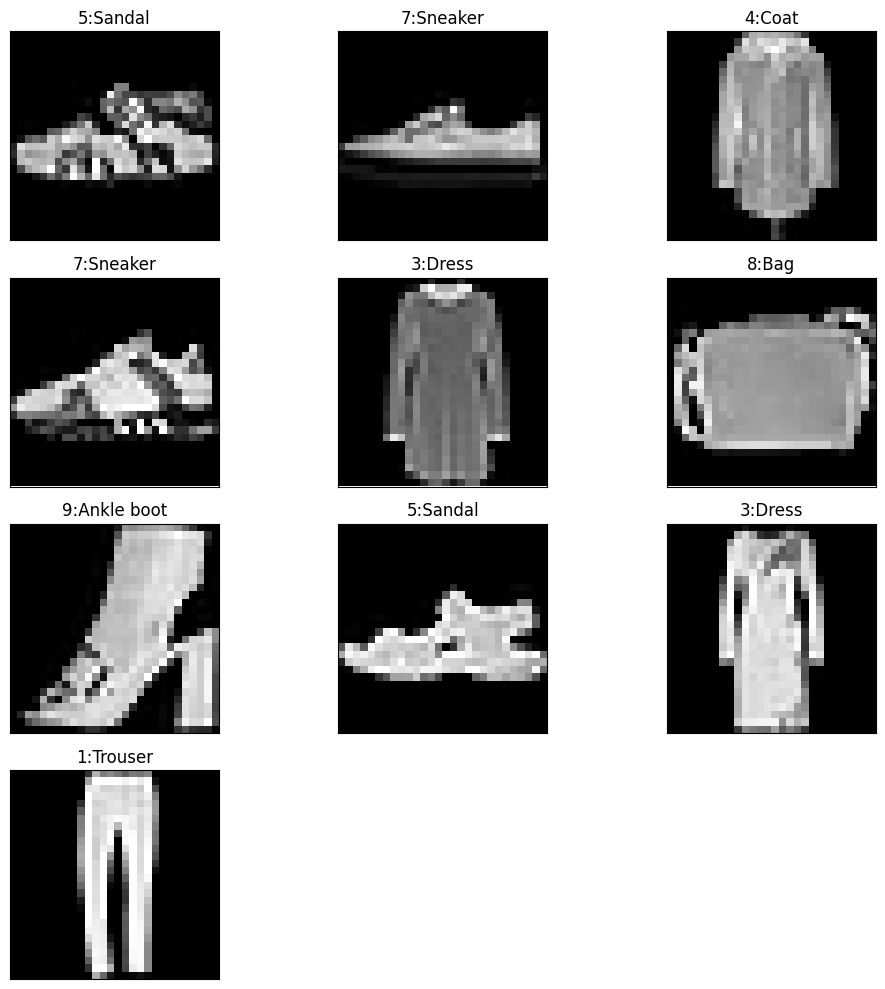

In [ ]:
def viz_img(train_loader, num_images=20):
  fig = plt.figure(figsize=(10,10))
  imgs, labels = next(iter(train_loader))

  rows = 4
  cols = int(np.ceil(num_images/rows))


  for idx in range(min(num_images,len(imgs))):
    img,label=imgs[idx],labels[idx]

    ax = fig.add_subplot(rows,cols, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(img),cmap='grey')
    ax.set_title(f'{label.item()}:{class_encode[label.item()]}')
  plt.tight_layout()
  plt.show()


viz_img(train_loader, num_images=10)

In [ ]:
class MLP (nn.Module):
  def __init__(self,num_classes):
    super().__init__()
    self.fc0 = nn.Linear(784,512)
    self.bn0 = nn.BatchNorm1d(512)
    self.fc1 = nn.Linear(512,256)
    self.bn1 = nn.BatchNorm1d(256)
    self.fc2 = nn.Linear(256,128)
    self.bn2 = nn.BatchNorm1d(128)
    self.fc3 = nn.Linear(128,64)
    self.bn3 = nn.BatchNorm1d(64)
    self.fc4 = nn.Linear(64, num_classes)

    self.dropout = nn.Dropout(p=0.3)

  def forward(self,x):
    x = x.view(x.shape[0],-1)

    x = F.relu(self.bn0(self.fc0(x)))
    x = self.dropout(x)

    x = F.relu(self.bn1(self.fc1(x)))

    x = F.relu(self.bn2(self.fc2(x)))
    x = self.dropout(x)

    x = F.relu(self.bn3(self.fc3(x)))

    x = F.log_softmax(self.fc4(x),dim=1)

    return x


mlp_model = MLP(num_classes = 10)

In [ ]:
print(summary(mlp_model, input_size = (1,1,28,28), row_settings = ["var_names"]))

Layer (type (var_name))                  Output Shape              Param #
MLP (MLP)                                [1, 10]                   --
├─Linear (fc0)                           [1, 512]                  401,920
├─BatchNorm1d (bn0)                      [1, 512]                  1,024
├─Dropout (dropout)                      [1, 512]                  --
├─Linear (fc1)                           [1, 256]                  131,328
├─BatchNorm1d (bn1)                      [1, 256]                  512
├─Linear (fc2)                           [1, 128]                  32,896
├─BatchNorm1d (bn2)                      [1, 128]                  256
├─Dropout (dropout)                      [1, 128]                  --
├─Linear (fc3)                           [1, 64]                   8,256
├─BatchNorm1d (bn3)                      [1, 64]                   128
├─Linear (fc4)                           [1, 10]                   650
Total params: 576,970
Trainable params: 576,970
Non-trainable

In [ ]:
criterion = F.nll_loss
optimizer = optim.Adam(mlp_model.parameters(),lr =1e-2)
num_epoch =40
device = 'cuda'if torch.cuda.is_available() else 'cpu'

In [ ]:
def train(model,train_loader,criterion,optimizer,device):
  model.train()
  model.to(device)
  running_loss=0
  correct_predictions = 0
  total_samples = 0

  for imgs,labels in train_loader:
    imgs,labels = imgs.to(device),labels.to(device)
    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()


    _ , predicted = torch.max(outputs.data, dim=1)
    total_samples += labels.size(0)
    correct_predictions += (predicted == labels).sum().item()

  avg_loss = running_loss/len(train_loader)
  accuracy = 100 * correct_predictions / total_samples
  return avg_loss, accuracy

In [ ]:
def validation (model, val_loader,criterion,device):
  model.eval()
  model.to(device)

  running_loss = 0
  correct_predictions = 0
  total_samples = 0

  for imgs,labels in val_loader:
    imgs,labels = imgs.to(device),labels.to(device)
    outputs = model(imgs)

    loss  = criterion(outputs,labels)
    running_loss += loss.item()
    _ , predicted = torch.max(outputs.data, 1)
    total_samples += labels.size(0)
    correct_predictions += (predicted == labels).sum().item()

  avg_loss = running_loss / len(val_loader)
  accuracy = 100 * correct_predictions / total_samples
  return avg_loss, accuracy


In [ ]:
def main (model, train_loader, val_loader, num_epoch=5, device = "cuda"):
  train_losses, val_losses = [], []
  train_accuracies, val_accuracies = [], []

  for epoch in range(num_epoch):
    train_loss, train_accuracy = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy = validation(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    print(f"Epoch {epoch+1:0>2}/{num_epoch} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}% - Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

  plt.figure(figsize=(12,5))
  plt.subplot(1, 2, 1)
  plt.plot(range(1, num_epoch + 1), train_losses, label='Train Loss')
  plt.plot(range(1, num_epoch + 1), val_losses, label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()


  plt.subplot(1, 2, 2)
  plt.plot(range(1, num_epoch + 1), train_accuracies, label='Train Accuracy')
  plt.plot(range(1, num_epoch + 1), val_accuracies, label='Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

Epoch 01/40 - Train Loss: 0.0000, Train Accuracy: 79.83% - Val Loss: 0.4442, Val Accuracy: 84.14%
Epoch 02/40 - Train Loss: 0.0000, Train Accuracy: 84.59% - Val Loss: 0.3854, Val Accuracy: 86.30%
Epoch 03/40 - Train Loss: 0.0000, Train Accuracy: 85.67% - Val Loss: 0.3852, Val Accuracy: 85.93%
Epoch 04/40 - Train Loss: 0.0000, Train Accuracy: 86.68% - Val Loss: 0.3682, Val Accuracy: 87.02%
Epoch 05/40 - Train Loss: 0.0000, Train Accuracy: 87.25% - Val Loss: 0.3671, Val Accuracy: 86.53%
Epoch 06/40 - Train Loss: 0.0000, Train Accuracy: 87.78% - Val Loss: 0.3453, Val Accuracy: 87.32%
Epoch 07/40 - Train Loss: 0.0000, Train Accuracy: 88.10% - Val Loss: 0.3338, Val Accuracy: 87.77%
Epoch 08/40 - Train Loss: 0.0000, Train Accuracy: 88.68% - Val Loss: 0.3298, Val Accuracy: 88.34%
Epoch 09/40 - Train Loss: 0.0000, Train Accuracy: 89.05% - Val Loss: 0.3234, Val Accuracy: 88.20%
Epoch 10/40 - Train Loss: 0.0000, Train Accuracy: 89.38% - Val Loss: 0.3152, Val Accuracy: 88.47%
Epoch 11/40 - Train 

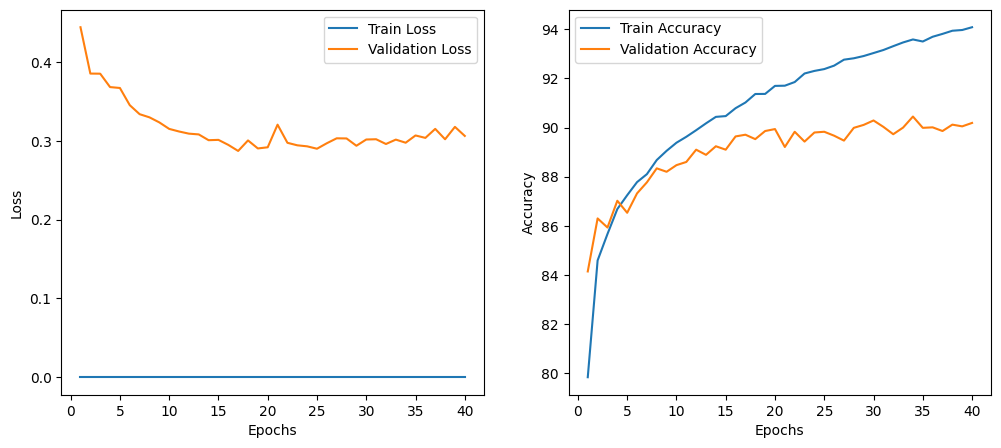

In [ ]:

main(mlp_model, train_loader, val_loader, num_epoch = num_epoch, device = device)

In [ ]:
zfrom math import e
def get_random_samples(dataset, n=4):
  img_data=[]
  label_data=[]
  imgs, gt_labels = next(iter(val_loader)) #first batch

  for _ in range(0,n+1):
   rand = rd.randint(0,len(imgs)-1)
   img,label = imgs[rand],gt_labels[rand]
   img_data.append(img)
   label_data.append(label)
  return img_data,label_data

def single_data(dataset):

  pic = cv2.imread(dataset,cv2.IMREAD_GRAYSCALE)


  my_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((28, 28), antialias=True),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(1),
    lambda x: 1 - x,
    transforms.Normalize((0.5,), (0.5,))
  ])

  the_pic = my_transform(pic).unsqueeze(0)

  plt.imshow(pic,cmap='gray')
  plt.show()


  return the_pic



def display_samples(img_samples,Label_samples):

  fig, axs = plt.subplots(2,2,figsize=(5,6))
  axs = axs.flatten()
  i=0
  for ax,img,label in zip(axs,img_samples,Label_samples):

   ax.imshow(img[0],cmap='gray')
   ax.set_xticks([])
   ax.set_yticks([])
   ax.set_title(f'{i}. {class_encode[label.item()]}')
   i+=1


  fig.suptitle("Make Ai Predict ", fontsize=16)
  plt.tight_layout()
  plt.show()


def get_user_choice():
  choice  = int(input("\ninput the number of a PIC. :\n "))

  return choice

def Predict (model,img_samples,choice = None,device=device):
  model.eval()
  model.to(device)

  with torch.no_grad():
    if choice == None:
      model_prob = model(img_samples.to(device))
    else:
      model_prob = model(img_samples[choice].to(device))
  prob_score = model_prob.softmax(dim=1).cpu()


  fig = plt.figure(figsize=(8,4))
  plt.title(" the probability of it being : ")
  plt.barh(y=class_encode.values(), width=prob_score[0])

def  main2(model,dataset,device,From = 'fashion'):
  if  From == 'fashion' :
    img_samples,Label_samples = get_random_samples(dataset, n=4)
    display_samples(img_samples,Label_samples)
    time.sleep(0.1)
    choice = get_user_choice()
    Predict (model,choice,img_samples,device=device)
  else:
    img = single_data(dataset)
    time.sleep(0.1)
    Predict (model= model,img_samples = img,device=device)




 # RUN  the fucking 'Just Run' and ten run  main2 👍

In [ ]:
# Pic  = '/content/GooGle_tshirt.jpeg'
Pic = "/content/123A9852.jpg"

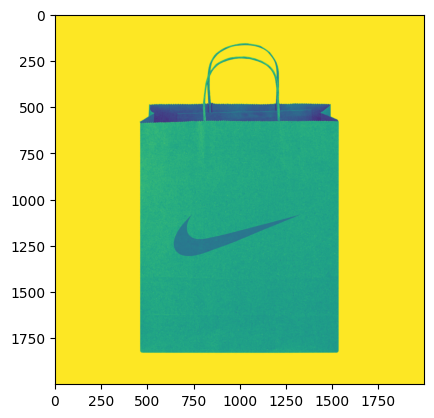

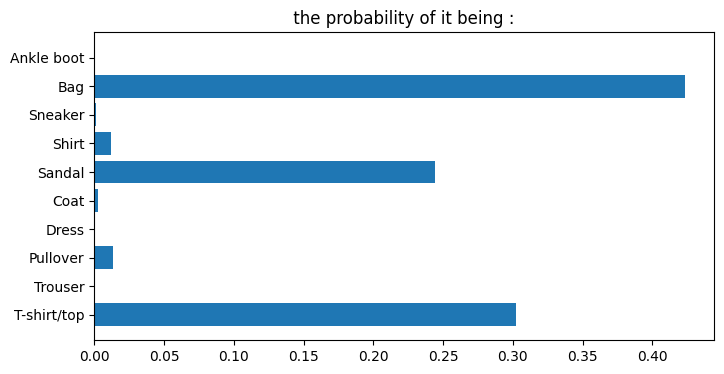

In [ ]:
# main2(model=mlp_model,dataset = val_loader,device=device,From = 'fashion')
main2(model=mlp_model,dataset = Pic,device=device,From = 'GOOGLE')

In [ ]:
print(class_encode)

{0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0
0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0
0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 0 0
0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 0 0
0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 0
0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0
0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0
0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 

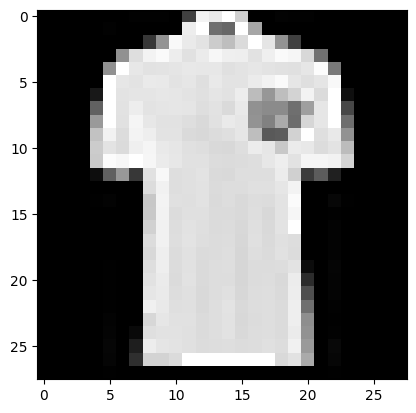

In [ ]:
img, labe = next(iter(train_loader))

image = img[0]  # shape [3, H, W]

# Convert to grayscale by averaging across channels
gray = image.mean(0)

# Normalize to [0,1]
gray = (gray - gray.min()) / (gray.max() - gray.min())

# Binarize: threshold at 0.5
binary = (gray > 0.5).int()

# Print as grid of 0s and 1s
for row in binary:
    print(" ".join(str(int(val)) for val in row.tolist()))

plt.imshow(img[0].squeeze(),cmap='gray')

In [ ]:
class_encode={
0 : 'T-shirt/top',
1 : 'Trouser',
2 : 'Pullover',
3 : 'Dress',
4 : 'Coat',
5 : 'Sandal',
6: 'Shirt',
7: 'Sneaker',
8: 'Bag',
9: 'Ankle boot'}

for val in class_encode.values():
  print(val ,'\n')

T-shirt/top 

Trouser 

Pullover 

Dress 

Coat 

Sandal 

Shirt 

Sneaker 

Bag 

Ankle boot 

